# Proyecto de mapeo de clientes

### Importar los paquetes

In [1]:
# Importar los paquetes
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd



### Levantar las fuentes del mapa

- https://gadm.org/
- https://gadm.org/download_country.html Load the GeoJSON file (Level 1 - regions) 

In [ ]:
# Sacar la fuente de donde salen los mapas

# https://gadm.org/
# https://gadm.org/download_country.html
# Load the GeoJSON file (Level 1 - regions) 
geojson_path = 'C:\\Users\\JuanCarlosSaraviaDra\\Downloads\\gadm41_PER_1.json\\gadm41_PER_1.json'
peru_regions = gpd.read_file(geojson_path) # Esto es un dataframe

peru_regions = peru_regions.reset_index() # crear una columna con el index que servirá para juntar las provincias


### Esta es la data de marketing para la geolocation

In [ ]:
# Data de marketing geolocation

source_marketing = 'C:\\Users\\JuanCarlosSaraviaDra\\Downloads\\marketing_geolocation.csv'

data_marketing = pd.read_csv(source_marketing)


### Generar un filtro que selecciona a todas las personas que son clientes

In [ ]:
# Filtrar todas las personas que son clientes
data_marketing_clients = data_marketing.loc[data_marketing['user_id'].notna()]


### Filtrar a todas las personas que no son clientes

In [ ]:
## No son clientes
data_marketing_none_clients = data_marketing.loc[~data_marketing['user_id'].notna()]

### Agregar la data de los clientes para revisar en qué regiones están

- Aquí como los nombres de las regiones eran diferentes pero en el mismo orden utilicé el indez como primary key para no estar cambiando los nombres

In [ ]:
# Agregar la data de los clientes 

data_marketing_clients = data_marketing_clients.loc[data_marketing_clients['country'] == "Peru"]

data_marketing_clients_region_Peru = data_marketing_clients.groupby(['region']).agg(
    Clientes = ('region', 'count')).reset_index()

data_marketing_clients_region_Peru = data_marketing_clients_region_Peru.reset_index()


### Agregar la data de los no clientes para ver a qué regiones pertenecen

- Aquí como los nombres de las regiones eran diferentes pero en el mismo orden utilicé el indez como primary key para no estar cambiando los nombres

In [34]:
### Agregar la data de los no clientes

data_marketing_none_clients = data_marketing_none_clients.loc[data_marketing_none_clients['country'] == "Peru"]

data_marketing_none_clients_region_Peru = data_marketing_none_clients.groupby(['region']).agg(
    Clientes = ('region', 'count')).reset_index()

data_marketing_none_clients_region_Peru = data_marketing_none_clients_region_Peru.reset_index()


### Juntar los data frames de los clientes

- **Nota**: en Lima los data frames tienen etiquetas invertidas pero se revisó que sean realmente lo mismo.  

In [44]:
# Merge tables
data_final_clientes = pd.merge(peru_regions, data_marketing_clients_region_Peru, how='inner', left_on= 'index', right_on='index').reset_index()

data_final_clientes

,level_0,index,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry,region,Clientes
0,0,0,PER.1_1,PER,Peru,Amazonas,NA,NA,Región,Region,01,PE.AM,PE-AMA,"MULTIPOLYGON (((-77.7803 -6.942, -77.7842 -6.9...",Amazonas,528
1,1,1,PER.2_1,PER,Peru,Ancash,Ancachs,NA,Región,Region,02,PE.AN,PE-ANC,"MULTIPOLYGON (((-77.2862 -10.5582, -77.292 -10...",Ancash,9184
2,2,2,PER.3_1,PER,Peru,Apurímac,Apuromac,NA,Región,Region,03,PE.AP,NA,"MULTIPOLYGON (((-73.2403 -13.4763, -73.2363 -1...",Apurimac,280
3,3,3,PER.4_1,PER,Peru,Arequipa,NA,NA,Región,Region,04,PE.AR,PE-ARE,"MULTIPOLYGON (((-71.8424 -17.1726, -71.8482 -1...",Arequipa,25304
4,4,4,PER.5_1,PER,Peru,Ayacucho,NA,NA,Región,Region,05,PE.AY,PE-AYA,"MULTIPOLYGON (((-73.2933 -15.3921, -73.3067 -1...",Ayacucho,1952
5,5,5,PER.6_1,PER,Peru,Cajamarca,Caxamarca,NA,Región,Region,06,PE.CJ,PE-CAJ,"MULTIPOLYGON (((-77.8269 -7.3524, -77.8213 -7....",Cajamarca,6996
6,6,6,PER.7_1,PER,Peru,Callao,ElCallao,NA,Provincia,Province,07,PE.CL,NA,"MULTIPOLYGON (((-77.2326 -12.1296, -77.2351 -1...",Callao Region,11391
7,7,7,PER.8_1,PER,Peru,Cusco,Cuzco|Qosqo,NA,Región,Region,08,PE.CS,PE-CUS,"MULTIPOLYGON (((-71.0532 -15.4263, -71.0575 -1...",Cusco,9466
8,8,8,PER.9_1,PER,Peru,Huancavelica,NA,NA,Región,Region,09,PE.HV,PE-HUV,"MULTIPOLYGON (((-74.7775 -14.0364, -74.774 -14...",Huancavelica,239
9,9,9,PER.10_1,PER,Peru,Huánuco,Huknuco,NA,Región,Region,10,PE.HC,NA,"MULTIPOLYGON (((-76.4796 -10.3294, -76.4726 -1...",Huanuco,5529


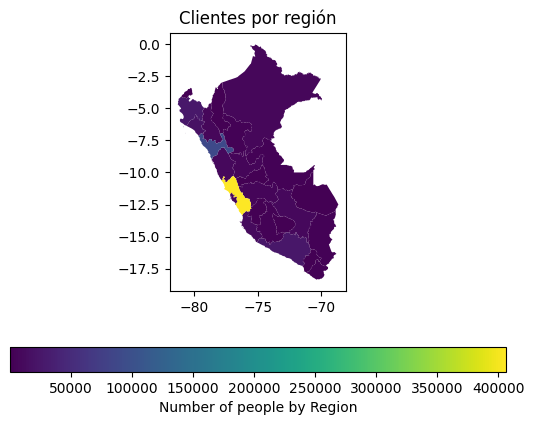

In [41]:
# Plot the data, with color intensity based on the number of cases
data_final.plot(column='Clientes', cmap='viridis', legend=True,
            legend_kwds={'label': "Number of people by Region",
                         'orientation': "horizontal"})

plt.title('Clientes por región')
plt.show()

In [47]:
Clientes_resumen = data_final[['NAME_1', 'Clientes']]
Clientes_resumen

,NAME_1,Clientes
0,Amazonas,528
1,Ancash,9184
2,Apurímac,280
3,Arequipa,25304
4,Ayacucho,1952
5,Cajamarca,6996
6,Callao,11391
7,Cusco,9466
8,Huancavelica,239
9,Huánuco,5529


### Juntar con el data frame de los no clientes



In [45]:
# Merge tables
data_final_no_clientes = pd.merge(peru_regions, data_marketing_none_clients_region_Peru, how='inner', left_on= 'index', right_on='index').reset_index()

data_final_no_clientes

,level_0,index,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry,region,Clientes
0,0,0,PER.1_1,PER,Peru,Amazonas,NA,NA,Región,Region,01,PE.AM,PE-AMA,"MULTIPOLYGON (((-77.7803 -6.942, -77.7842 -6.9...",Amazonas,8072
1,1,1,PER.2_1,PER,Peru,Ancash,Ancachs,NA,Región,Region,02,PE.AN,PE-ANC,"MULTIPOLYGON (((-77.2862 -10.5582, -77.292 -10...",Ancash,141243
2,2,2,PER.3_1,PER,Peru,Apurímac,Apuromac,NA,Región,Region,03,PE.AP,NA,"MULTIPOLYGON (((-73.2403 -13.4763, -73.2363 -1...",Apurimac,5023
3,3,3,PER.4_1,PER,Peru,Arequipa,NA,NA,Región,Region,04,PE.AR,PE-ARE,"MULTIPOLYGON (((-71.8424 -17.1726, -71.8482 -1...",Arequipa,378497
4,4,4,PER.5_1,PER,Peru,Ayacucho,NA,NA,Región,Region,05,PE.AY,PE-AYA,"MULTIPOLYGON (((-73.2933 -15.3921, -73.3067 -1...",Ayacucho,28961
5,5,5,PER.6_1,PER,Peru,Cajamarca,Caxamarca,NA,Región,Region,06,PE.CJ,PE-CAJ,"MULTIPOLYGON (((-77.8269 -7.3524, -77.8213 -7....",Cajamarca,103704
6,6,6,PER.7_1,PER,Peru,Callao,ElCallao,NA,Provincia,Province,07,PE.CL,NA,"MULTIPOLYGON (((-77.2326 -12.1296, -77.2351 -1...",Callao Region,139859
7,7,7,PER.8_1,PER,Peru,Cusco,Cuzco|Qosqo,NA,Región,Region,08,PE.CS,PE-CUS,"MULTIPOLYGON (((-71.0532 -15.4263, -71.0575 -1...",Cusco,150810
8,8,8,PER.9_1,PER,Peru,Huancavelica,NA,NA,Región,Region,09,PE.HV,PE-HUV,"MULTIPOLYGON (((-74.7775 -14.0364, -74.774 -14...",Huancavelica,5412
9,9,9,PER.10_1,PER,Peru,Huánuco,Huknuco,NA,Región,Region,10,PE.HC,NA,"MULTIPOLYGON (((-76.4796 -10.3294, -76.4726 -1...",Huanuco,93144


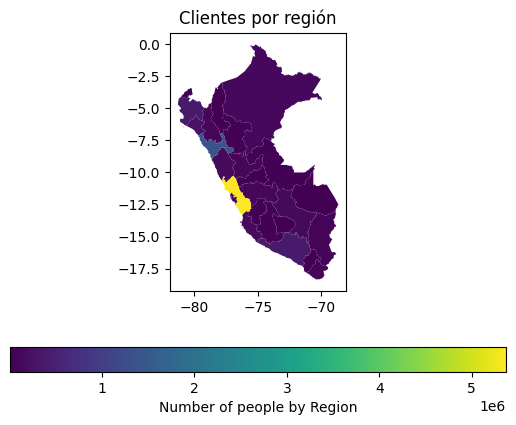

In [43]:
# Plot the data, with color intensity based on the number of cases
data_final_no_clientes.plot(column='Clientes', cmap='viridis', legend=True,
            legend_kwds={'label': "Number of people by Region",
                         'orientation': "horizontal"})

plt.title('Clientes por región')
plt.show()

In [48]:
No_Clientes_resumen = data_final_no_clientes[['NAME_1', 'Clientes']]
No_Clientes_resumen

,NAME_1,Clientes
0,Amazonas,8072
1,Ancash,141243
2,Apurímac,5023
3,Arequipa,378497
4,Ayacucho,28961
5,Cajamarca,103704
6,Callao,139859
7,Cusco,150810
8,Huancavelica,5412
9,Huánuco,93144
